# **PERSAMAAN HIPERBOLIK - PART 2**

In [ ]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

## **Karakteristik**

Secara umum dalam menyelesaikan persamaan diferensial parsial hiperbolik.Yang dimana secara analitik adala persamaan yang menggunakan metode karakteristik, tetapi hingga saat ini kita benar-benar belum mencoba menggunakan teori ini untuk membangun metode numerik.

Adapun mengenai nilai solusi pada titik $(x_j, t + \Delta t)$, kita ketahui bahwa untuk $a > 0$, kita melihat ke belakang ke titik $(x_j - a \Delta t, t)$ yang mana solusi di sana memberikan informasi tentang solusi pada titik yang diminati.

Hal ini bekerja dengan baik sampai kita mulai memikirkan grid terdiskritisasi di mana kita hanya mengetahui solusi pada waktu $t$ pada himpunan titik diskret.

![alt text](image.png)

Jika karakteristik yang berpotongan dengan $(x_j, t + \Delta t)$ juga berpotongan dengan titik pada waktu $t$, maka kita baik-baik saja. Biasanya ini tidak akan terjadi kecuali kita secara khusus memilih $\Delta x$ dan $\Delta t$ sedemikian rupa sehingga ini benar. Ternyata, tentu saja, ini terjadi jika
$$
    \frac{a \Delta t}{\Delta x} = 1,
$$

persis batas atas dari hasil stabilitas kita.

![alt text](image-1.png)

Demikian pula jika $\nu < 1$ maka kita tahu bahwa karakteristik tidak akan tepat mengenai titik-titik grid. Perhatikan juga bahwa karena kendala bahwa $|\nu| \leq 1$, kita tahu bahwa karakteristik tidak dapat melewati $x_{j-1}$.

Kita juga bisa malah menginterpolasi antara dua nilai yang dibelah oleh karakteristik dan menemukan nilai yang dimaksud. Tunjukkan bahwa melakukan ini menggunakan interpolasi linier mengarah pada metode upwind.

Untuk interpolasi linier kita tahu bahwa persimpangan berada di $x_p = x_j - a \Delta t$. Interpolan linier adalah
$$\begin{aligned}
    P_1(x) &= \frac{x - x_{j-1}}{x_{j} - x_{j-1}} U^n_{j} + \frac{x - x_j}{x_{j-1} - x_j} U^n_{j-1} \\
    & = \frac{x - x_{j-1}}{\Delta x} U^n_{j} - \frac{x - x_j}{\Delta x} U^n_{j-1}
\end{aligned}$$

sehingga nilai adalah
$$\begin{aligned}
    U^{n+1}_j = P_1(x_j - a \Delta t) &= \frac{x_j - a \Delta t - x_{j-1}}{\Delta x} U^n_{j} - \frac{x_j - a \Delta t - x_j}{\Delta x} U^n_{j-1} \\
    &= \frac{\Delta x - a \Delta t}{\Delta x} U^n_{j} + \frac{a \Delta t}{\Delta x} U^n_{j-1} \\
    &= U^n_{j} - \frac{a \Delta t}{\Delta x} (U^n_{j} - U^n_{j-1}).
\end{aligned}$$

Menggunakan teknik serupa kita juga dapat menemukan metode Beam-Warming dengan interpolasi kuadratik:
$$\begin{aligned}
    P_2(x) &= \frac{(x - x_{j-1})(x - x_{j-2})}{(x_{j} - x_{j-1}) (x_{j} - x_{j-2})} U^n_{j} + \frac{(x - x_{j})(x - x_{j-2})}{(x_{j-1} - x_{j}) (x_{j-1} - x_{j-2})} U^n_{j-1} + \frac{(x - x_{j})(x - x_{j-1})}{(x_{j-2} - x_{j}) (x_{j-2} - x_{j-1})} U^n_{j-2} \\
    &=\frac{(x - x_{j-1})(x - x_{j-2})}{2 \Delta x^2} U^n_{j} - \frac{(x - x_{j})(x - x_{j-2})}{\Delta x^2} U^n_{j-1} + \frac{(x - x_{j})(x - x_{j-1})}{2 \Delta x^2} U^n_{j-2} \\
    &=\frac{1}{\Delta x^2} \left[\frac{1}{2} U^n_{j} (x - x_{j-1})(x - x_{j-2}) - U^n_{j-1} (x - x_{j})(x - x_{j-2}) + \frac{1}{2} U^n_{j-2} (x - x_{j})(x - x_{j-1}) \right ]
\end{aligned}$$
dan akhirnya
$$\begin{aligned}
    U^{n+1}_j = P_2(x_j - a \Delta t) &= \frac{1}{\Delta x^2} \left[\frac{1}{2} U^n_{j} (\Delta x - a \Delta t)(2 \Delta x - a \Delta t) - U^n_{j-1} (- a \Delta t)(2 \Delta x - a \Delta t) + \frac{1}{2} U^n_{j-2} (- a \Delta t)(\Delta x - a \Delta t) \right ] \\
    &= \frac{1}{\Delta x^2} \left[\frac{1}{2} U^n_{j} (2 \Delta x^2 - 3 a \Delta t \Delta x + a \Delta t^2) - U^n_{j-1} (-2a \Delta t \Delta x + a^2 \Delta t^2) + \frac{1}{2} U^n_{j-2} (-a \Delta t \Delta x + a^2 \Delta t^2) \right ] \\
    &= U^n_j - \frac{a \Delta t}{2 \Delta x} (3 U^n_j - 4 U^n_{j-1} + U^n_{j-2}) + \frac{a \Delta t^2}{2 \Delta x^2} (U^n_j - 2 U^n_{j-1} + U^n_{j-2})
\end{aligned}$$

## **Kondisi Courant-Friedrichs-Lewy (CFL)**

Salah satu hasil menarik dari analisis karakteristik kita adalah bahwa kriteria stabilitas menyebabkan persimpangan karakteristik dengan $t_n$ berada dalam interval $[x_{j-1}, x_j]$ ketika $a > 0$. Ini menunjukkan prinsip yang lebih umum untuk stabilitas numerik PDE, yang dikemukakan oleh Courant, Friedrichs, dan Lewy dan sering disebut kondisi CFL.

Kondisi stabilitas yang telah kita amati berulang kali
$$
    \nu = \left | \frac{a \Delta t}{\Delta x} \right | \leq 1
$$
ternyata merupakan kondisi yang diperlukan untuk metode yang dikembangkan untuk menyelesaikan persamaan adveksi. Nilai $\nu$ sering disebut *bilangan Courant* karena ini.

### *Domain Ketergantungan*

Untuk membuat pernyataan yang lebih umum tentang kondisi CFL dan bilangan Courant, kita perlu membahas apa itu *domain ketergantungan* untuk PDE tertentu. Kita sudah tahu apa ini untuk persamaan adveksi. Kita tahu bahwa solusi pada $(X, T)$ adalah $u(X, T) = u_0(X - a T)$. Domain ketergantungan kemudian adalah
$$
    \mathcal{D}(X,T) = \{X - a T\}.
$$
Cara lain untuk memikirkannya adalah dengan mempertimbangkan titik-titik mana yang bisa kita ubah yang akan mempengaruhi solusi pada $(X,T)$. Dalam kasus persamaan adveksi, itu adalah satu titik.

Lebih umum lagi untuk PDE lainnya, kita mungkin mengharapkan domain ketergantungan lebih besar dari satu titik saja, tetapi sebaliknya merupakan himpunan titik (seperti dalam kasus sistem persamaan adveksi) atau seluruh interval. Persamaan panas adalah salah satu persamaan seperti itu dan memiliki domain ketergantungan $\mathcal{D}(X, T) = (-\infty, \infty)$. Dengan kata lain, semua titik di domain mempengaruhi semua titik lainnya pada waktu mendatang. Jenis persamaan ini juga dikatakan memiliki *kecepatan propagasi* tak hingga dan merupakan kasus untuk setiap PDE parabolik dan merupakan cara lain untuk mengklasifikasikan PDE yang lebih kompleks.

Seseorang mungkin menolak ide ini untuk persamaan panas setelah semua fungsi Green untuk titik tertentu meluruh secara eksponensial cepat dari titik tersebut, tetapi sayangnya masih belum cukup cepat. Ini juga merupakan sumber dari kesimpulan dan kerusakan fisik dari model difusi, materi (atau panas) akan bergerak dengan kecepatan tak hingga.

### *Domain Ketergantungan Numerik*

Metode numerik juga memiliki domain ketergantungan yang ditentukan oleh stencil yang digunakan. Misalnya, metode Lax-Friedrichs memiliki solusi $U^n_j$ yang bergantung pada titik-titik $U^{n-1}_{j+1}$, $U^{n-1}_{j}$, dan $U^{n-1}_{j-1}$. Ini umumnya benar untuk metode tiga titik yang kita kembangkan sebelumnya termasuk metode Lax-Wendroff.

Kita juga dapat melacak ke belakang lebih jauh dalam waktu untuk melihat titik-titik mana $U^{n-1}_{j+1}$, $U^{n-1}_{j}$, dan $U^{n-1}_{j-1}$ bergantung untuk melihat kerucut ketergantungan yang berkembang.

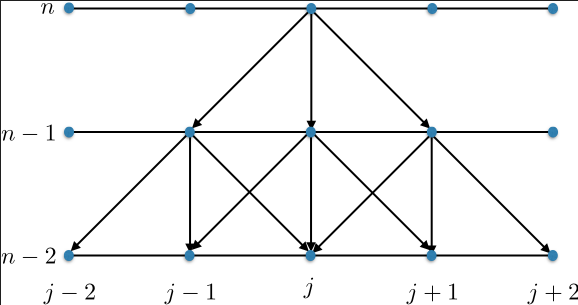

Seiring grid diperbaiki baik dalam waktu maupun ruang dengan menghormati kriteria stabilitas (kondisi CFL), kita mungkin mengharapkan bahwa domain ketergantungan numerik mungkin konvergen ke yang sebenarnya. Ini sebenarnya tidak benar untuk stencil tiga titik tetapi sebenarnya kondisi yang lebih lemah berlaku, bahwa domain ketergantungan numerik harus mengandung domain ketergantungan PDE.

Jika kita katakan terus memperbaiki grid kita dengan rasio antara $\Delta t / \Delta x = r$ maka domain ketergantungan untuk titik $(X,T)$ akan mengisi interval $[X - T/ r, X+ T/r]$. Karena kita ingin solusi terkomputasi $U(X,T)$ konvergen ke solusi sebenarnya $u_0(X - a T)$, kita perlu memerlukan
$$
    X - T/r \leq X - a T \leq X + T /r.
$$
Ini pada dasarnya menyiratkan bahwa $u_0(X - aT)$ terletak dalam kerucut ketergantungan numerik. Ini juga menyiratkan bahwa $|a| \leq 1 /r$ dan oleh karena itu $|a \Delta t / \Delta x| \leq 1$ lagi memberikan kita kriteria stabilitas yang familiar. Ini kemudian mengarah pada pernyataan umum kondisi CFL.

Kondisi CFL kemudian dapat diringkas dalam kondisi yang diperlukan berikut:
> Metode numerik konvergen hanya jika domain ketergantungan numeriknya mengandung domain ketergantungan yang ditentukan dari PDE asli saat $\Delta t \rightarrow 0$ dan $\Delta x \rightarrow 0$.

### **Contoh** - Metode Upwind

Domain numerik bergantung pada tanda $a$ tetapi memiliki stencil 2 titik. Perhatikan bahwa jika kita memilih arah yang salah untuk upwinding bahwa saat $\Delta t$ dan $\Delta x$ mendekati 0 titik $X - a T$ tidak akan pernah terletak dalam kerucut ketergantungan.

### **Contoh** - Persamaan Panas

Kita telah menyebutkan bahwa domain ketergantungan sebenarnya untuk persamaan panas adalah seluruh domain. Bagaimana itu bekerja untuk persamaan panas kemudian, terutama dengan metode implisit?

Ini menyiratkan bahwa setiap stencil 3-titik (yang telah kita gunakan) sebenarnya melanggar kondisi CFL. Ini memang benar jika kita memperbaiki rasio $\Delta t / \Delta x$ tetapi sebenarnya kita memiliki persyaratan yang lebih ketat untuk hubungan tersebut, bahwa $\Delta t / \Delta x^2 \leq 1 / 2$. Ini memperluas domain ketergantungan saat $\Delta t \rightarrow 0$ cukup cepat sehingga akan mencakup seluruh domain.

Untuk metode implisit, seperti Crank-Nicholson, kondisi CFL terpenuhi untuk setiap langkah waktu $\Delta t$ karena kopling setiap titik ke setiap titik lainnya.

## **Persamaan Modifikasi**

Alat kuat lainnya untuk menganalisis metode numerik adalah penggunaan persamaan modifikasi. Pendekatan ini mirip dengan apa yang kita gunakan untuk mendapatkan kesalahan pemotongan lokal dan mengungkap lebih banyak tentang bagaimana kita mungkin mengharapkan metode numerik tertentu untuk berperforma dan seperti apa kesalahannya mungkin muncul.

Ide dasarnya adalah menemukan PDE baru yang mungkin diselesaikan **secara tepat** oleh metode numerik. Dengan kata lain jika kita memiliki PDE $v_t = f(v, v_x, v_{xx}, \cdots)$ maka solusi perkiraan kita dengan beberapa $\Delta t$ dan $\Delta x$ akan memuaskan $U^n_j = v(x_j, t_n)$. Pertanyaan juga dapat diajukan "apakah ada PDE yang $U^n_j$ lebih baik menangkap?". Kita dapat menjawab pertanyaan ini melalui ekspansi seri Taylor.

### **Contoh** - Metode Upwind

Metode upwind adalah
$$
    U^{n+1}_j = U^n_j - \frac{a \Delta t}{\Delta x} (U^n_j - U^n_{j-1}).
$$
dengan asumsi $a > 0$. Asumsikan bahwa kita memiliki fungsi $v(x,t)$ dan PDE terkait (yang belum kita ketahui) yang diselesaikan secara tepat oleh metode upwind.

Pertama ganti solusi diskret $U$ dengan fungsi kontinyu $v(x,t)$ sehingga kita memiliki
$$
    v(x, t + \Delta t) = v(x,t) - \frac{a \Delta t}{\Delta x} (v(x,t) - v(x-\Delta x,t)).
$$

Menggunakan seri Taylor kita tahu
$$\begin{aligned}
    \left(v + v_t \Delta t + \frac{\Delta t^2}{2} v_{tt} + \frac{\Delta t^3}{6} v_{ttt} + \cdots \right ) - v + \frac{a \Delta t}{\Delta x} \left( v - v + \Delta x v_x + \frac{\Delta x^2}{2} v_{xx} - \frac{\Delta x^3}{6} v_{xxx} + \cdots \right ) = 0\\    
    v_t + \frac{\Delta t}{2} v_{tt} + \frac{\Delta t^2}{6} v_{ttt} + \cdots + a \left( v_x + \frac{\Delta x}{2} v_{xx} - \frac{\Delta x^2}{6} v_{xxx} + \cdots \right ) = 0.
\end{aligned}$$
Mengatur ulang suku-suku dalam persamaan kita memiliki
$$
    v_t + a v_x = \frac{1}{2}(a \Delta x v_{xx} - \Delta t v_{tt}) + \frac{1}{6} (a \Delta x^2 v_{xxx} - \Delta t^2 v_{ttt}) + \cdots
$$
Ini adalah PDE yang dipuaskan oleh $v$.

Kita dapat melihat di sini bahwa jika $\Delta t$ dan $\Delta x$ mendekati nol kita dapat mengharapkan bahwa kita akan memulihkan persamaan asli yang dimaksudkan untuk diselesaikan oleh metode. Namun, suku dominan di sisi kanan memberikan kita gambaran tentang perilaku solusi $v$ jika $\Delta t$ dan $\Delta x$ tidak nol. Misalnya jika kita mempertimbangkan suku $\mathcal{O}(\Delta x, \Delta t)$ kita memiliki persamaan
$$
    v_t + a v_x = \frac{1}{2}(a \Delta x v_{xx} - \Delta t v_{tt}),
$$
persamaan yang juga mencakup sesuatu yang terlihat seperti persamaan gelombang orde kedua. Kita dapat menulis ulang ini bahkan lebih eksplisit dengan mendiferensiasikan kedua sisi terhadap $t$
$$
    v_{tt} = -a v_{xt} + \frac{1}{2} (a \Delta x v_{xxt} - \Delta t v_{ttt})
$$
dan terhadap $x$
$$
    v_{tx} = -a v_{xx} + \frac{1}{2} (a \Delta x v_{xxx} - \Delta t v_{ttx})
$$
yang dikombinasikan mengarah ke
$$
    v_{tt} = a^2 v_{xx} + \mathcal{O}(\Delta t).
$$

Memasukkan ini kembali ke ekspresi asli di sisi kanan kita dapat menghilangkan turunan orde kedua dalam waktu untuk menemukan
$$
    v_t + a v_x = \frac{1}{2} a \Delta x \left(1 - \frac{a \Delta t}{\Delta x} \right) v_{xx} + \mathcal{O}(\Delta x^2, \Delta t^2)
$$
yang merupakan persamaan adveksi-difusi mirip dengan yang kita lihat sebelumnya kecuali sekarang diformulasikan secara eksplisit dalam kasus kontinyu. Kita juga dapat mengatakan bahwa diskritisasi upwind memberikan solusi untuk persamaan adveksi-difusi di atas dengan akurasi orde kedua.

Jadi apa yang dapat kita ambil dari ini?  
 - Perilaku orde utama ini membuat kita percaya bahwa kesalahannya akan bersifat difusif.
 - Jika $a \Delta t = \Delta x$, yaitu bilangan Courant $\nu = 1$, maka solusi tepat akan dipulihkan.
 - Koefisien di depan operator difusi adalah $\frac{1}{2} (a \Delta x - a^2 \Delta t)$ yang positif jika $0 < a \Delta t / \Delta x < 1$, cara lain untuk melihat kriteria stabilitas.

 ### **Contoh** - Lax-Wendroff

Mengikuti prosedur yang sama kita dapat mendapatkan suku orde utama (hingga $\mathcal{O}(\Delta t^2, \Delta x^2)$) untuk Lax-Wendroff untuk menemukan
$$
    v_t + a v_x = -\frac{1}{6} a \Delta x^2 \left( 1 - \left(\frac{a \Delta t}{\Delta x}\right)^2 \right) v_{xxx}.
$$
Kita dapat mengamati beberapa hal dari persamaan modifikasi ini
 - Lax-Wendroff mendekati persamaan adveksi-dispersi hingga orde ketiga.
 - Kesalahan dominan akan bersifat dispersif (turunan ketiga melakukan ini) meskipun kesalahan ini akan lebih kecil daripada kesalahan difusif dari metode upwind di atas.

 #### **Catatan Samping - Dispersi**

Pertimbangkan PDE
$$
    u_t = u_{xxx}
$$
sebagai masalah Cauchy. Jika kita transformasi Fourier persamaan tersebut kita sampai pada ODE
$$
    \hat{u~}_t(\xi,t) = - i \xi^3 \hat{u~}(\xi, t)
$$
yang memiliki solusi
$$
    \hat{u~}(\xi, t) = \hat{u~}_0(\xi) e^{-i \xi^3 t}.
$$

Perhatikan bahwa ini terlihat seperti solusi umum untuk masalah adveksi di mana gelombang akan mempertahankan amplitudonya, namun setiap mode Fourier sekarang menyebar pada kecepatannya sendiri tergantung pada bilangan gelombangnya. Kita dapat melihat ini dengan mengambil transformasi Fourier invers untuk menemukan
$$
    u(x,t) = \frac{1}{\sqrt{2 \pi}} \int^\infty_{-\infty} \hat{u~}_0(\xi) e^{i\xi(x - \xi^2 t)} d\xi.
$$

Memeriksa integrand kita dapat melihat bahwa bilangan gelombang $\xi$ bergerak pada kecepatan $\xi^2$. Sebaliknya jalur serupa dengan persamaan adveksi mengarah ke
$$
    u(x,t) = \frac{1}{\sqrt{2 \pi}} \int^\infty_{-\infty} \hat{u~}_0(\xi) e^{i\xi(x - a t)} d\xi
$$
di mana kita jelas melihat semua bilangan gelombang $\xi$ bergerak pada kecepatan $a$. Ini adalah perbedaan esensial antara adveksi dan dispersi, komponen solusi menyebar karena kecepatan efektif mereka yang berbeda.

Kita dapat memperluas ini ke persamaan yang lebih umum dari bentuk
$$
    u_t + a u_x + b u_{xxx} = 0
$$
di mana kita dapat menulis solusi
$$
    u(x,t) = \frac{1}{\sqrt{2 \pi}} \int^\infty_{-\infty} \hat{u~}_0(\xi) e^{i \xi (x - (a - b\xi^2) t)} d\xi.
$$
Di sini kita melihat kecepatan komponen bergerak pada $a - b \xi^2$ sehingga nilai relatif $a$ dan $b$ akan menentukan efek mana yang akan lebih dominan.

Kembali ke persamaan modifikasi metode Lax-Wendroff kita dapat menulis kecepatan grup sebagai
$$
    c_g = a - \frac{1}{2} a \Delta x^2 \left(1 - \left( \frac{a \Delta t}{\Delta x} \right )^2 \right) \xi^2.
$$
Untuk metode khusus ini $c_g < a$ untuk semua $\xi$ dan oleh karena itu kesalahan dispersi mengikuti gelombang seperti yang terlihat dalam contoh numerik.

Kita juga dapat mempertahankan lebih banyak suku dalam persamaan modifikasi, jika kita melakukan ini hingga orde keempat kita akan menemukan
$$
    v_t + a v_x + \frac{1}{6} a \Delta x^2 \left(1 - \left( \frac{a \Delta t}{\Delta x} \right )^2 \right) v_{xxx} + \epsilon v_{xxxx} = 0
$$
di mana $\epsilon = \mathcal{O}(\Delta x^3 + \Delta t^3)$. Kita sekarang melihat bahwa di luar kesalahan dispersif kita akan menemukan hiper-difusi sebagai kesalahan utama.

Dispersi dan berbicara tentang bilangan gelombang $\xi$ juga membawa pertimbangan penting lainnya. Jika kita tertarik pada gelombang yang sangat osilatori relatif terhadap grid, yaitu ketika $\xi \Delta x \gg

### **Contoh** : Beam-Warming

Sebagai kontras dengan perilaku kesalahan Lax-Wendroff pertimbangkan persamaan modifikasi untuk metode Beam-Warming yang adalah
$$
    v_t + a v_x = \frac{1}{6} a \Delta x^2 \left ( 2- \frac{3 a \Delta t}{\Delta x} + \left(\frac{a \Delta t}{\Delta x} \right)^2 \right ) v_{xxx}.
$$
Kita melihat dengan contoh numerik bahwa kesalahan dispersi mendahului gelombang dan kita sekarang dapat melihat mengapa karena dalam kasus ini $c_g > a$.

### **Contoh** : Leapfrog

Persamaan modifikasi untuk leapfrog mengarah pada beberapa kesimpulan menarik karena kita memiliki beberapa pembatalan yang beruntung. Menulis metode leapfrog sebagai
$$
    \frac{v(x, t + \Delta t) - v(x, t - \Delta t)}{2 \Delta t} + a \frac{v(x + \Delta x, t) - v(x - \Delta x, t)}{2 \Delta x} = 0
$$
kita dapat mengamati bahwa persamaan modifikasi mengambil bentuk
$$
    v_t + a v_x + \frac{1}{6} a \Delta x^2 \left(1 - \left( \frac{a \Delta t}{\Delta x} \right )^2 \right) v_{xxx} = \epsilon_1 v_{xxxxx} + \epsilon_2 v_{xxxxxxx} + \cdots.
$$
Ternyata semua suku turunan orde genap hilang meninggalkan kita hanya dengan kesalahan dispersif. Faktanya hingga orde keempat diskritisasi leapfrog menyelesaikan persamaan adveksi-dispersi. Kita juga dapat melihat sekarang lagi mengapa leapfrog harus disebut non-dissipatif karena tidak ada suku kesalahan yang memiliki turunan genap, yaitu difusi tidak hadir.

Sebagai latihan lebih lanjut kita juga dapat menghitung hubungan dispersi tepat dari metode numerik (hubungan dispersi menghubungkan bilangan gelombang $\xi$ dengan kecepatan fase, biasanya dilambangkan $\omega(\xi)$). Memasukan ansatz familiar serupa dengan analisis von Neumann $e^{i(\xi x_j - \omega t_n)}$ kita memiliki
$$
    e^{-i\omega \Delta t} = e^{i \omega \Delta t} - \frac{a \Delta t}{\Delta x} \left( e^{i \xi \Delta x} - e^{-i\xi \Delta x}\right)
$$
mengarah ke
$$
    \sin(\omega \Delta t) = \frac{a \Delta t}{\Delta x} \sin(\xi \Delta x).
$$

Kita juga dapat menghitung kecepatan grup $c_g$ dari ini karena
$$
    c_g = \frac{\text{d} \omega}{\text{d} \xi} = \frac{a \cos(\xi \Delta x)}{\cos(\omega \Delta t)} = \pm \frac{a \cos(\xi \Delta x)}{\sqrt{1 - \nu^2 \sin^2(\xi \Delta x)}}.
$$
Perhatikan lagi apa yang terjadi jika $\nu = 1$.

## **Sistem Persamaan Hiperbolik**

Kita dapat memperluas apa yang telah kita lakukan sejauh ini ke sistem PDE hiperbolik (linier) dari bentuk
$$
    u_t + A u_x = 0
$$
dengan kondisi awal yang sesuai $u(x,0) = u_0(x)$. Di sini $A \in \mathbb R^{s \times s}$ di mana $s$ adalah jumlah persamaan.

Dalam kasus ini ada cara yang terdefinisi dengan baik untuk memperluas ide sebelumnya tentang PDE hiperbolik karena kita memerlukan $A$ untuk dapat didiagonalisasikan dengan eigenvalu real agar sistem PDE disebut hiperbolik. Konsekuensinya adalah bahwa kita dapat menulis $A$ sebagai
$$
    A = R \Lambda R^{-1}
$$
di mana $R$ adalah eigenvector dengan $\Lambda$ mengandung eigenvalu pada diagonalnya. Eigenvalu ini menggantikan nilai yang kita lihat sebelumnya sebagai kecepatan adveksi $a$ sehingga ini real dan terbatas cocok dengan ide sebelumnya tentang apa yang seharusnya dimiliki oleh persamaan hiperbolik, informasi menyebar pada kecepatan terbatas.

Meskipun kurang trivial kita masih dapat menyelesaikan sistem hiperbolik linier karena dekomposisi $A$. Memasukan dekomposisi dan mengalikan dengan $R^{-1}$ di sebelah kanan mengarah ke
$$
    u_t + R \Lambda R^{-1} u_x = 0 \Rightarrow \\
    R^{-1} u_t + \Lambda R^{-1} u_x = 0.
$$

Mendefinisikan *variabel karakteristik* sebagai $w = R^{-1} u$ kita dapat menulis ulang sistem sebagai himpunan persamaan yang terpisah dengan
$$
    w_t + \Lambda w_x = 0.
$$
Kita tahu bagaimana menyelesaikan ini sebagai $w_p(x,t) = w_p(x - \lambda_p t, 0)$. Kondisi awal dalam variabel karakteristik adalah
$$
    w(x, 0) = R^{-1} u_0(x).
$$

Mengubah kembali ke variabel asli kita pada prinsipnya hanya perlu mengevaluasi
$$
    u(x,t) = R w(x,t)
$$
namun ini tidak begitu mudah karena bentuk solusi dalam $w$. Sebaliknya kita dapat menulis solusi sebagai
$$
    u(x,t) = \sum^s_{p=1} w_p(x,t) r_p = \sum^s_{p=1}w_p(x - \lambda_p t, 0) r_p.
$$

Kita sekarang memiliki *karakteristik dari keluarga ke-p* yang merujuk pada kelompok ke-p karakteristik yang ditentukan oleh eigenvalu ke-p.

### *Metode Numerik*

Kita dapat memperluas sebagian besar metode yang telah kita bahas sejauh ini ke sistem dengan hanya mengganti kecepatan adveksi $a$ dengan matriks $A$. Misalnya metode Lax-Wendroff dapat digeneralisasikan ke
$$
     U^{n+1}_j = U^n_j - \frac{\Delta t}{2 \Delta x} A (U^n_{j+1} - U^n_{j-1})  + \frac{ \Delta t^2}{2 \Delta x^2} A^2 (U^n_{j+1} - 2 U^n_{j} + U^n_{j-1})
$$
dengan syarat bahwa bilangan Courant $\nu < 1$. Perhatikan sekarang kita perlu berhati-hati tentang bilangan Courant karena secara umum kondisi CFL memerlukan bahwa
$$
    \nu = \max_{1 \leq p \leq s} \left| \frac{\lambda_p \Delta t}{\Delta x} \right | < 1
$$
Semua aproksimasi berbasis terpusat umumnya berlaku dengan kriteria stabilitas ini.

Metode yang telah kita pertimbangkan yang satu sisi namun memerlukan sedikit lebih hati-hati kecuali semua eigenvalu matriks $A$ positif atau negatif. Sebaliknya kita harus mendekomposisi sistem ke dalam variabel karakteristiknya, menerapkan metode per persamaan, dan mentransformasi kembali. Umumnya jenis metode ini diklasifikasikan sebagai *metode Godunov*.

## **Boundaries (Batas)**

Seringkali banyak yang mengabaikan batas di luar periodik. Oleh karena itu, kita pertimbangkan bagaimana menggabungkan batas untuk menemukan metode menyelesaikan masalah nilai batas awal.

Pertimbangan PDE hiperbolik yang didefinisikan oleh
$$
    u_t + a u_x = 0 ~~~~ \Omega = [0, 1] \\
    u(x, 0) = u_0(x)
$$
sebelum mendefinisikan kondisi batas. Karena diskusi domain ketergantungan kita tahu sedikit tentang kapan batas akan mempengaruhi solusi kita.

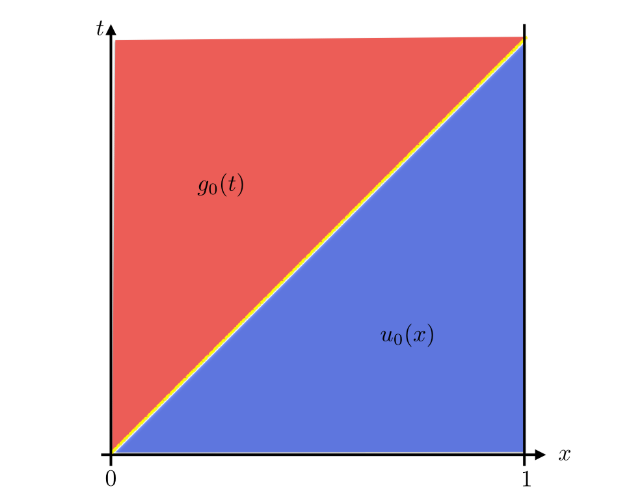

Untuk persamaan skalar dan $a > 0$ maka kita tahu
$$
    u(x,t) = \left \{ \begin{aligned}
        u_0(x - a t) & & 0 \leq x - at \leq 1 \\
        g_0(t - x / a) & & \text{otherwise}.
    \end{aligned} \right .
$$

Jika kita memiliki sistem persamaan dengan tanda berlawanan untuk kecepatan kita mungkin memiliki situasi yang terlihat seperti berikut sebaliknya

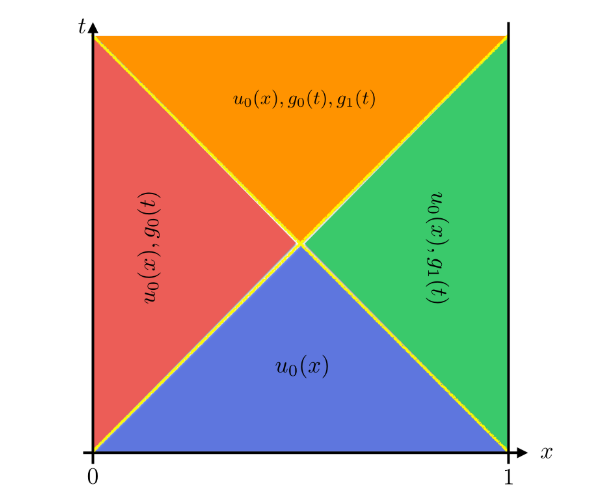

### *Upwind untuk IBVP*

Katakan kita menggunakan metode upwind yang sesuai untuk $a > 0$ dengan grid $\Delta x = 1 / (m + 1)$. Upwind mendeskripsikan semua persamaan internal dengan kondisi pada batas kiri memberikan nilai $U_0$, oleh karena itu metode sepenuhnya menentukan masalah. Metode stabil dengan kondisi yang sama seperti sebelumnya.

Perhatikan bahwa kita tidak lagi dapat langsung menggunakan analisis von Neumann karena batas baru. Ini masih dapat berguna sebagai alat stabilitas namun analisis metode garis dapat lebih berguna di sini.

Pertimbangkan lagi sistem ODE
$$
    U'(t) = A U(t) + g(t)
$$
di mana
$$
    A = - \frac{a}{\Delta x} \begin{bmatrix}
        1 \\
        -1 & 1 \\
        & -1 & 1 \\
        & & \ddots & \ddots \\
        & & & -1 & 1
    \end{bmatrix} \quad g(t) = \begin{bmatrix} g_0(t) \frac{a}{\Delta x} \\ 0 \\ \vdots \\ 0 \end{bmatrix}.
$$

Sayangnya matriks baru ini, meskipun mirip dengan yang dipertimbangkan sebelumnya, memiliki sifat yang sangat berbeda. Matriks baru ini memiliki eigenvalu yang terdistribusi seragam di sekitar lingkaran dengan radius $a / \Delta x$ dan berpusat di $z = - a / \Delta x$.

Mengapa perubahan ini signifikan? Jika kita mengikuti analisis sebelumnya kita akan menyimpulkan bahwa metode stabil jika
$$
    0 \leq \nu \leq 2
$$
yang sedikit mencurigakan. Ternyata ini adalah kondisi yang diperlukan (meskipun jelas tidak cukup). Masalah dalam analisis kita berasal dari fakta bahwa $A$ sangat non-normal dan kita memerlukan kendala lebih lanjut pada $\epsilon$-pseudospectra yang lagi mengarah pada kendala stabilitas yang lebih familiar kita.

### *Batas Aliran Keluar*

Seperti yang disebutkan sebelumnya, sering kali metode numerik yang ingin kita gunakan akan memerlukan penggunaan kondisi batas di mana tidak ada yang seharusnya ada. Kita melihat ini dengan metode Lax-Wendroff di mana titik batas aliran keluar diperlukan oleh stencil. Kita dapat menentukan *kondisi batas numerik* atau *kondisi batas buatan* sebagai ganti menggunakan aproksimasi satu sisi. Penentuan kondisi batas numerik panjang dan analisisnya rumit jadi di sini kita akan membatasi diri pada beberapa contoh ilustratif

#### **Contoh**

Pertimbangkan metode leapfrog pada domain terbatas dengan $a > 0$ dan kondisi batas inflow yang diberikan $g_0(t)$.  Katakanlah kita menggunakan metode upwind pada batas outflow alih-alih memberikan kondisi.  Ternyata melakukan hal tersebut akan memperkenalkan gelombang dengan $\xi \Delta x \approx \pi$ yang akan bergerak ke kiri dengan kecepatan $-a$.

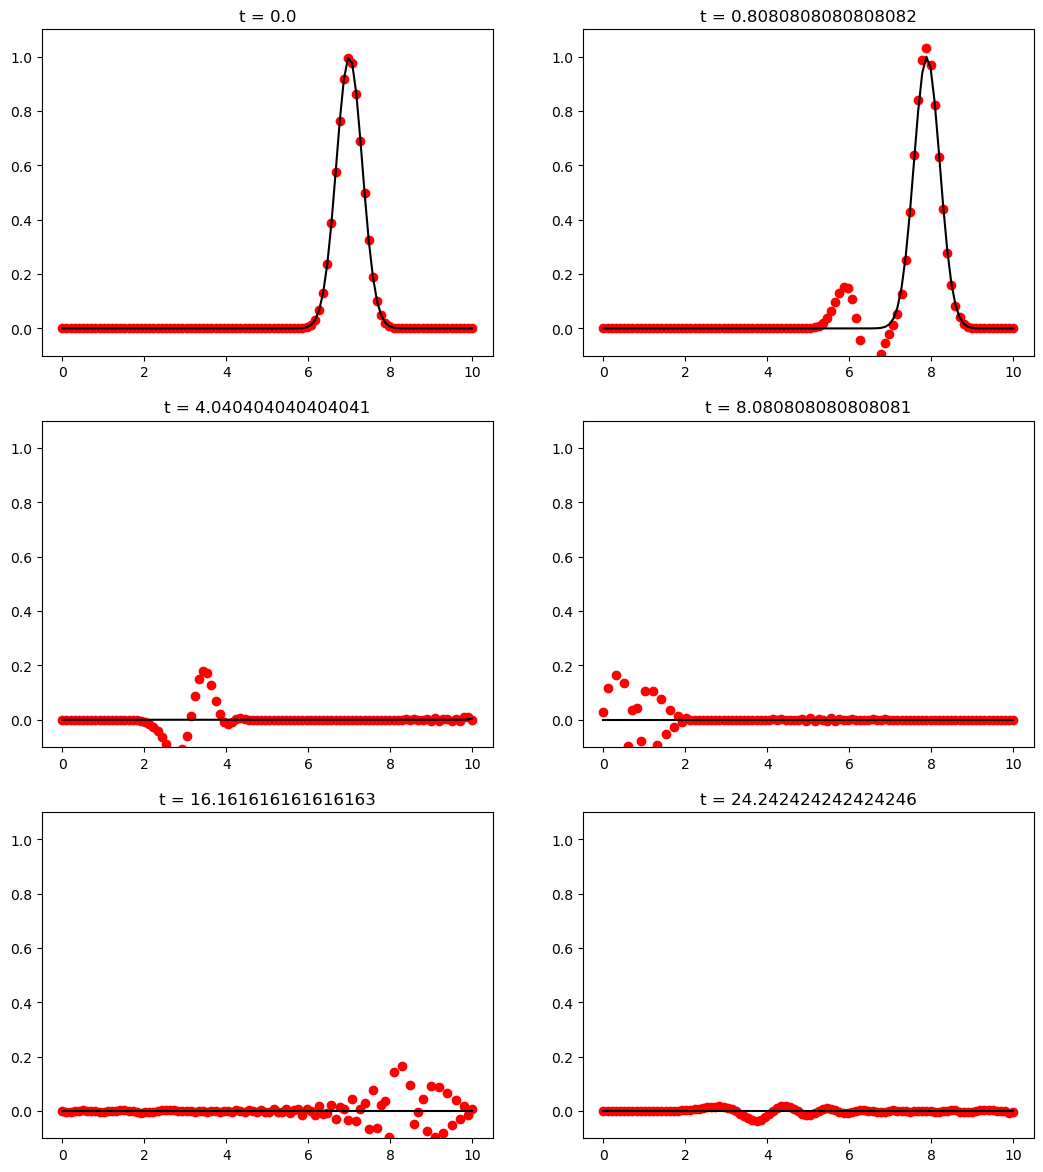

In [2]:
# Implement Leapfrog for the PDE u_t + u_x = 0 on a finite domain [0, 10]
# domain

import numpy as np
import matplotlib.pyplot as plt

u_true = lambda x, t: np.exp(-5.0 * ((x - t - 7.0)**2))

m = 100
x = np.linspace(0, 10.0, m)
delta_x = 10.0 / (m - 1)
cfl = 0.8

delta_t = cfl * delta_x

U = u_true(x, 0)
t = 0.0
# Jump start with true-solution
U_new = u_true(x, t + delta_t)
U_old = U_new.copy()

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 3)
axes = fig.add_subplot(3, 2, 1)
axes.plot(x, U, 'ro')
axes.plot(x, u_true(x, t),'k')
axes.set_ylim((-0.1, 1.1))
axes.set_title("t = 0.0")

t += delta_t
for (n, t_final) in enumerate((10*delta_t, 50 * delta_t, 100 * delta_t, 200 * delta_t, 300 * delta_t)):
    while t < t_final:
        U_new[0] = U_old[0] - delta_t / delta_x * (U[1] - u_true(0.0, t))
        U_new[1:-1] = U_old[1:-1] - delta_t / delta_x * (U[2:] - U[:-2])
        # Use upwind for outflow boundary
        U_new[-1] = U[-1] - delta_t / delta_x * (U[-1] - U[-2])
        U_old = U.copy()
        U = U_new.copy()
        t += delta_t

    # Plot solution at t = 17.0 and t = 0.0
    axes = fig.add_subplot(3, 2, n + 2)
    axes.plot(x, U, 'ro')
    axes.plot(x, u_true(x, t),'k')
    axes.set_ylim((-0.1, 1.1))
    axes.set_title("t = %s" % t_final)

plt.show()

## **Alternatif**

Akhirnya kita mengakhiri diskusi ini dengan beberapa alternatif yang tidak disebutkan di atas.

### *Diskritisasi Orde Tinggi*

Kita tentu saja dapat menggunakan diskritisasi orde tinggi secara sewenang-wenang di luar apa yang kita bahas di atas dengan menggunakan metode garis dan mendiskritisasi ruang dan waktu
$$
    U_j'(t) = -a W_j(t)
$$
dengan asumsi solusi tetap cukup halus.  Salah satu contohnya bisa jadi 
$$
    W_j(t) = \frac{4}{3} \left(\frac{U_{j+1} - U_{j-1}}{2 \Delta x} \right )- \frac{1}{3} \left(\frac{U_{j+2} - U_{j-2}}{4 \Delta x} \right ).
$$
Diskritisasi beda hingga yang dibahas sejauh ini semuanya dapat digunakan tetapi akurasi orde tinggi yang kita capai datang dengan biaya stencil yang lebih lebar yang menyebabkan kesulitan untuk alasan biasa.  

Pendekatan lain untuk menghindari ini adalah menggunakan metode beda kompak yang menyelesaikan sistem linier.  Contoh sederhana dari ide ini adalah
$$
    \frac{1}{4} W_{j-1} + W_j + \frac{1}{4} W_{j+1} = \frac{3}{2} \left( \frac{U_{j+1} - U_{j-1}}{2 \Delta x} \right )
$$
yang menghasilkan aproksimasi $\mathcal{O}(\Delta x^4)$.

### *Metode Spektral*

Kita juga dapat menggunakan metode spektral untuk mengubah turunan spasial menjadi sistem linier.  Pada dasarnya kita dapat memperoleh matriks diferensiasi padat $D$ sehingga $W = D U$.  Ini dapat dengan mudah digeneralisasi ke sistem persamaan yang lebih kompleks tetapi memerlukan solusi yang halus untuk bekerja dan dapat sangat sulit dianalisis.

### *Diskritisasi Waktu Lainnya*

Kita tentu saja juga dapat menggunakan diskritisasi waktu yang berbeda.  Di atas kita menggunakan apa yang terlihat seperti forward Euler dan leapfrog tetapi Anda dapat menggunakan metode eksplisit orde tinggi seperti metode Runge-Kutta atau metode implisit.  Metode implisit dapat berguna jika Anda tidak terlalu peduli dengan akurasi tetapi ingin mengembangkan solusi ke waktu yang besar.  Juga, meskipun persamaan adveksi itu sendiri tidak kaku, beberapa PDE hiperbolik dapat kaku atau diskritisasi spasial juga dapat (seperti halnya dengan pendekatan spektral di atas).

### *Hukum Konservasi dan Metode Volume Hingga*

Kelas besar dan penting dari PDE hiperbolik adalah hukum konservasi dalam bentuk
$$
    u_t + f(u)_x = 0.
$$

Ini secara alami muncul di banyak bidang fisika dan menggambarkan evolusi kuantitas seperti massa, momentum, atau energi.  Salah satu sistem seperti itu adalah persamaan Euler yang menggambarkan dinamika gas kompresibel:
$$\begin{aligned}
    &\rho_t + (\rho u)_x = 0 \\
    &(\rho u)_t + (\rho u^2 + p)_x = 0 \\
    &(E)_t + [(E + p) u]_x = 0
\end{aligned}$$
menggambarkan densitas $\rho$, momentum $\rho u$ dan energi $E$ yang dikopel dengan persamaan keadaan yang sesuai yang menghubungkan tekanan, densitas, dan energi internal.

Cara yang lebih alami untuk merumuskan hukum konservasi adalah dengan bentuk integral dari persamaan yang sama.  Secara umum kita dapat menulis ini sebagai
$$
    \frac{\text{d}}{\text{d}t} \int^{x_2}_{x_1} u(x, t) dx = f(u(x_1,t)) - f(u(x_2, t)).
$$

Metode untuk menyelesaikan ini sering mengembangkan rata-rata sel dari $u$ daripada nilai titik.  Dalam hal ini aproksimasi kita $U^n_i$ dilihat sebagai rata-rata ini di atas sel grid $[x_{i-1/2}, x_{i+1/2}]$ dengan panjang $\Delta x$ dan berpusat di $x_i$.  Rata-rata sel kemudian akan menjadi
$$
    U^n_i \approx \frac{1}{\Delta x} \int^{x_{i+1/2}}_{x_{i-1/2}} u(x, t_n) dx.
$$
Metode volume hingga umumnya mengambil pendekatan ini dengan spesifikasi cara untuk mengevaluasi fungsi fluks sebagai tujuan numerik utama.